In [1]:
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
import torch.optim as optim 
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [2]:
# set random seeds for reproducibility
torch.manual_seed(42)

In [3]:
df = pd.read_csv("fmnist_small.csv")
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


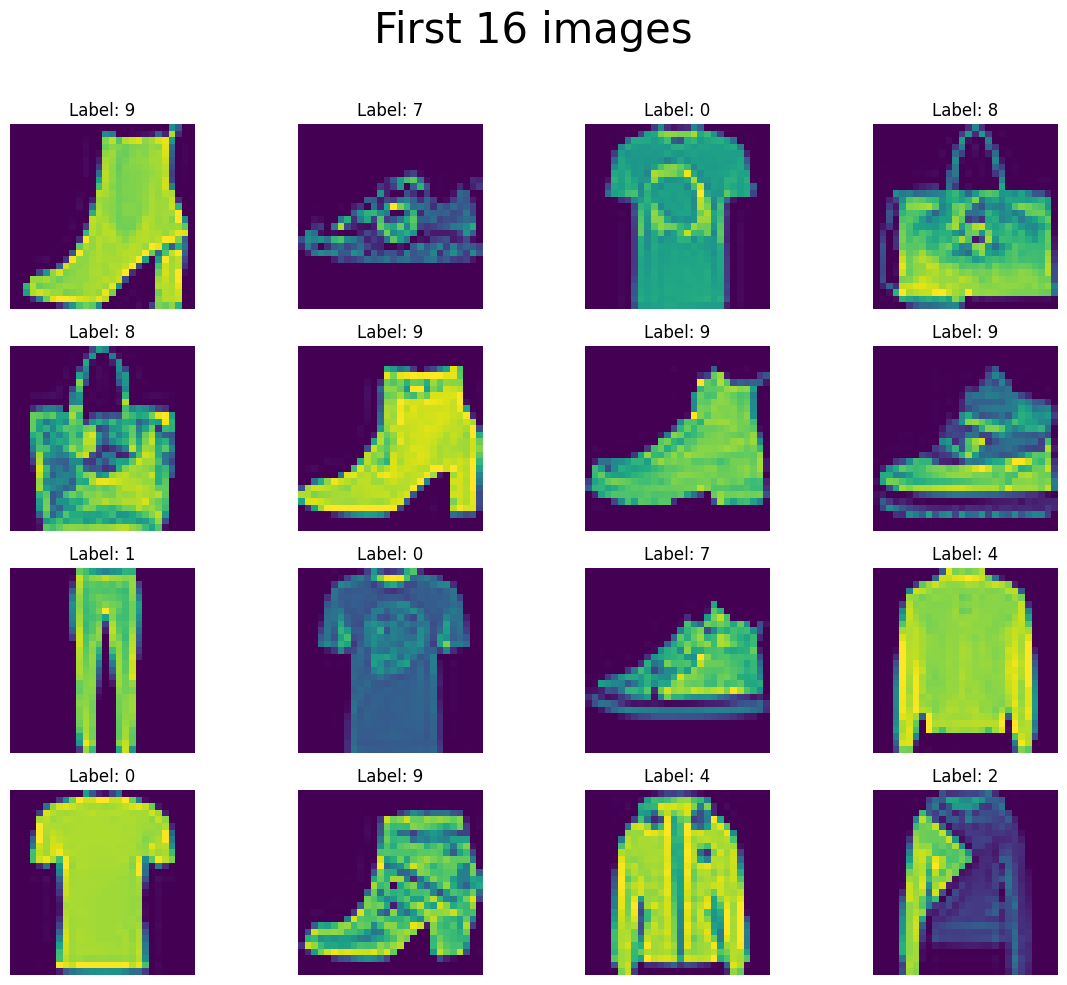

In [4]:
# visualizing data into 4x4 grid of images
fig, axes = plt.subplots(4,4, figsize = (12,10))
fig.suptitle("First 16 images", fontsize = 30)

for i, ax in enumerate(axes.flat):
    img = df.iloc[i,1:].values.reshape(28,28) # load img and reshape
    ax.imshow(img) #display in grayscale
    ax.axis('off')
    ax.set_title(f"Label: {df.iloc[i,0]}" ) # display the label

plt.tight_layout(rect = [0,0,1,0.96])
plt.show()

In [5]:
x = df.iloc[:,1:].values
y = df.iloc[:,0].values

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state=42)

In [7]:
# scaling the features
x_train = x_train/255.0
x_test = x_test/255.0

In [8]:
class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype= torch.float32).reshape(-1,1,28,28)
        self.labels = labels

    def __len__(self):
        return len(self.features)
    

    def __getitem__(self, index):
        return self.features[index], self.labels[index]


In [9]:
train_dataset = CustomDataset(x_train, y_train)
test_dataset = CustomDataset(x_test, y_test)


In [10]:
# create train and test loader

train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle = False)

In [15]:
# create model

class MyNN(nn.Module):

    def __init__(self, input_features):
        super().__init__()
        self.features_ext = nn.Sequential(
            nn.Conv2d(input_features, 32, kernel_size= 3, padding = "same"),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(kernel_size= 2, stride= 2),

            nn.Conv2d(32, 64, kernel_size= 3, padding = "same"),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size= 2, stride= 2)

        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(64*7*7, 128),
            nn.ReLU(),
            nn.Dropout(p = 0.4),

            nn.Linear(128 , 64),
            nn.ReLU(),
            nn.Dropout(p = 0.4),

            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.features_ext(x)
        x = self.classifier(x)

        return x

In [16]:
# set learning rate and epochs
learning_rate= 0.1
epochs = 100

In [17]:
# model create
model = MyNN(1)

#loss 
loss_function = nn.CrossEntropyLoss()

#optimizer
optimizer = optim.SGD(model.parameters(), lr = learning_rate)

In [18]:
# training loop

for epoch in range(epochs):
    total_epoch_loss = 0

    for batch_feature, batch_label in train_loader:
        y_pred = model(batch_feature) # forward pass

        loss = loss_function(y_pred, batch_label) #loss calculation

        optimizer.zero_grad() #clear gradient
        loss.backward() #doing back propagation

        optimizer.step() # parameters update

        total_epoch_loss += loss.item()

    avg_loss = total_epoch_loss/len(train_loader)
    print(f"Epoch: {epoch+1}, Loss: {avg_loss}")

Epoch: 1, Loss: 1.027728897134463
Epoch: 2, Loss: 0.6737377669413884
Epoch: 3, Loss: 0.5994428927699725
Epoch: 4, Loss: 0.5170770202080409
Epoch: 5, Loss: 0.48148008878032367
Epoch: 6, Loss: 0.4390467760960261
Epoch: 7, Loss: 0.4168161821862062
Epoch: 8, Loss: 0.37720694919427233
Epoch: 9, Loss: 0.35386298336088656
Epoch: 10, Loss: 0.3502862638483445
Epoch: 11, Loss: 0.2829266643772523
Epoch: 12, Loss: 0.271257773861289
Epoch: 13, Loss: 0.27214379963775476
Epoch: 14, Loss: 0.25569108076393604
Epoch: 15, Loss: 0.23349445872940122
Epoch: 16, Loss: 0.21363499599198502
Epoch: 17, Loss: 0.21750899776816368
Epoch: 18, Loss: 0.22026992084458472
Epoch: 19, Loss: 0.1754726001744469
Epoch: 20, Loss: 0.14980023299343884
Epoch: 21, Loss: 0.15092517477460204
Epoch: 22, Loss: 0.15071720367918412
Epoch: 23, Loss: 0.16618739803632102
Epoch: 24, Loss: 0.1632213938049972
Epoch: 25, Loss: 0.14675838231729965
Epoch: 26, Loss: 0.13410065736932059
Epoch: 27, Loss: 0.11196928681495288
Epoch: 28, Loss: 0.0975

In [19]:
# set model to evaluation mode
model.eval()

MyNN(
  (features_ext): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.4, inplace=False)
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [20]:
# evaluation code
total = 0
correct = 0
# on testing dataset
with torch.no_grad():
    for batch_feature, batch_label in test_loader:
        y_pred = model(batch_feature)
        _, predict = torch.max(y_pred, 1)

        total = total+ batch_label.shape[0]

        correct += (predict == batch_label).sum().item()
        
print(correct/total)



0.8625


In [21]:
# evaluation code
total = 0
correct = 0
# on training dataset
with torch.no_grad():
    for batch_feature, batch_label in train_loader:
        y_pred = model(batch_feature)
        _, predict = torch.max(y_pred, 1)

        total = total+ batch_label.shape[0]

        correct += (predict == batch_label).sum().item()
        
print(correct/total)



1.0


In [25]:
from torchinfo import summary
summary(model, input_size=(32, 1 ,28,28))


Layer (type:depth-idx)                   Output Shape              Param #
MyNN                                     [32, 10]                  --
├─Sequential: 1-1                        [32, 64, 7, 7]            --
│    └─Conv2d: 2-1                       [32, 32, 28, 28]          320
│    └─ReLU: 2-2                         [32, 32, 28, 28]          --
│    └─BatchNorm2d: 2-3                  [32, 32, 28, 28]          64
│    └─MaxPool2d: 2-4                    [32, 32, 14, 14]          --
│    └─Conv2d: 2-5                       [32, 64, 14, 14]          18,496
│    └─ReLU: 2-6                         [32, 64, 14, 14]          --
│    └─BatchNorm2d: 2-7                  [32, 64, 14, 14]          128
│    └─MaxPool2d: 2-8                    [32, 64, 7, 7]            --
├─Sequential: 1-2                        [32, 10]                  --
│    └─Flatten: 2-9                      [32, 3136]                --
│    └─Linear: 2-10                      [32, 128]                 401,536
│   